In [26]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:

# load the model
model = keras.models.load_model("C:/python/IML_project/gender_classification_epoch_10.keras")

def predict_single_image(image_path):
    # load the img
    img = keras.utils.load_img(image_path, target_size=(256, 256))
    
    # plot the img
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # normalisation
    img_array = keras.utils.img_to_array(img)
    img_array = img_array / 255.0

    # gemini
    # Add a batch dimension. CNNs expect a batch of images: (batch_size, height, width, channels)
    img_array = np.expand_dims(img_array, axis=0) # Changes shape from (256,256,3) to (1,256,256,3)

    # prediction
    prediction = model.predict(img_array)
    score = prediction[0][0]

    # show results results
    if score > 0.5:
        print(f"Result: Male ({score*100:.3f}% probability)")
    else:
        print(f"Result: Female ({(1 - score)*100:.3f}% probability)")



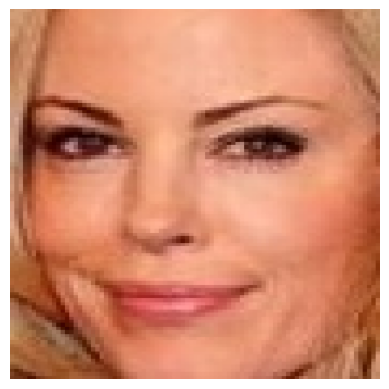

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Result: Female (99.999% probability)


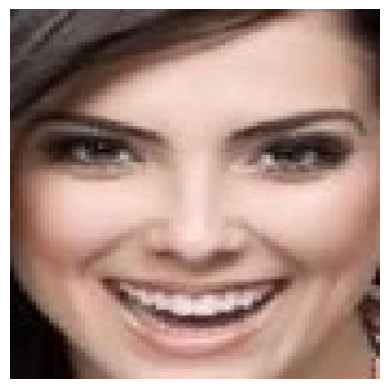

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Result: Female (100.000% probability)


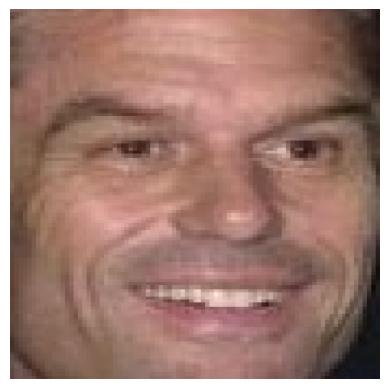

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Result: Male (99.856% probability)


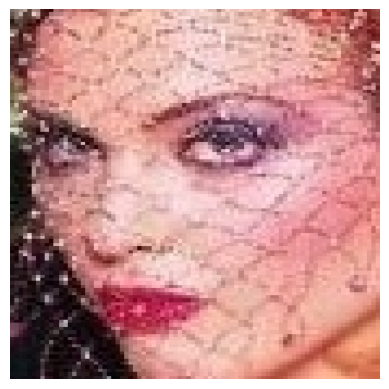

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Result: Male (99.033% probability)


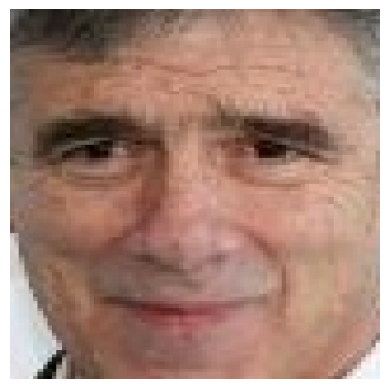

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Result: Male (100.000% probability)


In [ ]:
# test on some images
# 2nd male img is interesting!!!
predict_single_image("C:/python/IML_project/Validation/female/112950.jpg.jpg")
predict_single_image("C:/python/IML_project/Validation/female/112959.jpg.jpg")
predict_single_image("C:/python/IML_project/Validation/male/063495.jpg.jpg")
predict_single_image("C:/python/IML_project/Validation/male/063613.jpg.jpg")
predict_single_image("C:/python/IML_project/Validation/male/063543.jpg.jpg")

In [29]:
valid_dataset= keras.utils.image_dataset_from_directory(
    directory= 'C:/python/IML_project/Validation',
    labels= 'inferred',
    label_mode = 'int',
    batch_size= 32,
    image_size = (256,256)
)

train_dataset= keras.utils.image_dataset_from_directory(
    directory= 'C:/python/IML_project/Training',
    labels= 'inferred',
    label_mode = 'int',
    batch_size= 32,
    image_size = (256,256)
)

def process(image,label):
    image=tf.cast(image/255. , tf.float32)
    return image, label

train_dataset=train_dataset.map(process)
valid_dataset=valid_dataset.map(process)



Found 11649 files belonging to 2 classes.
Found 47009 files belonging to 2 classes.


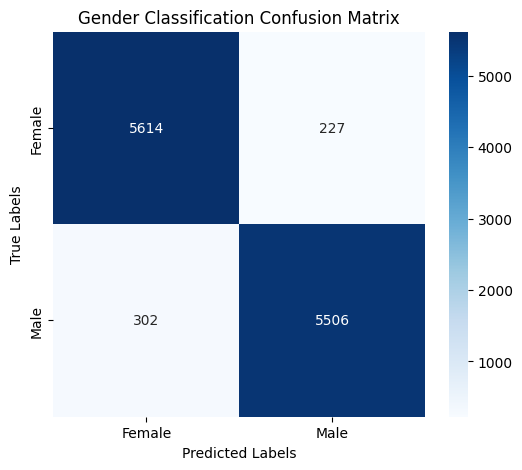


Classification Report:
              precision    recall  f1-score   support

      Female       0.95      0.96      0.96      5841
        Male       0.96      0.95      0.95      5808

    accuracy                           0.95     11649
   macro avg       0.95      0.95      0.95     11649
weighted avg       0.95      0.95      0.95     11649



In [ ]:
# Confusion matrix
y_true = []
y_pred = []

for images, labels in valid_dataset:
    y_true.extend(labels.numpy())
    
    preds = model.predict(images, verbose=0)
    
    # since its a sigmoid output, convert probabilities > 0.5 to class 1, else 0
    class_preds = (preds > 0.5).astype(int).flatten()
    y_pred.extend(class_preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute the confusion matrix values
cm = confusion_matrix(y_true, y_pred)

# Plotting the confusion matrix beautifully using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Female', 'Male'], 
            yticklabels=['Female', 'Male'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Gender Classification Confusion Matrix')
plt.show()

# Print detailed metrics (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Female', 'Male']))

In [ ]:
# what does the model missclassify & how badly
errors = []
y_prob = []
y_true_roc = []

for images, labels in valid_dataset:
    preds = model.predict(images, verbose=0).flatten()
    true_labels = labels.numpy()
    
    for i in range(len(true_labels)):
        true_val = true_labels[i]
        pred_val = preds[i]

        # for later
        y_prob.extend(preds)
        y_true_roc.extend(labels.numpy())

        # sort into binary classes
        pred_class = 1 if pred_val > 0.5 else 0
        
        # If it's a mistake
        if pred_class != true_val:
            # Calculate confidence of the wrong answer
            confidence = pred_val if pred_class == 1 else (1 - pred_val)
            errors.append({
                'image': images[i].numpy(),
                'true': true_val,
                'pred': pred_class,
                'conf': confidence,
                'index': i
            })

# Sort by confidence if needed
#errors = sorted(errors, key=lambda x: x['conf'], reverse=True)


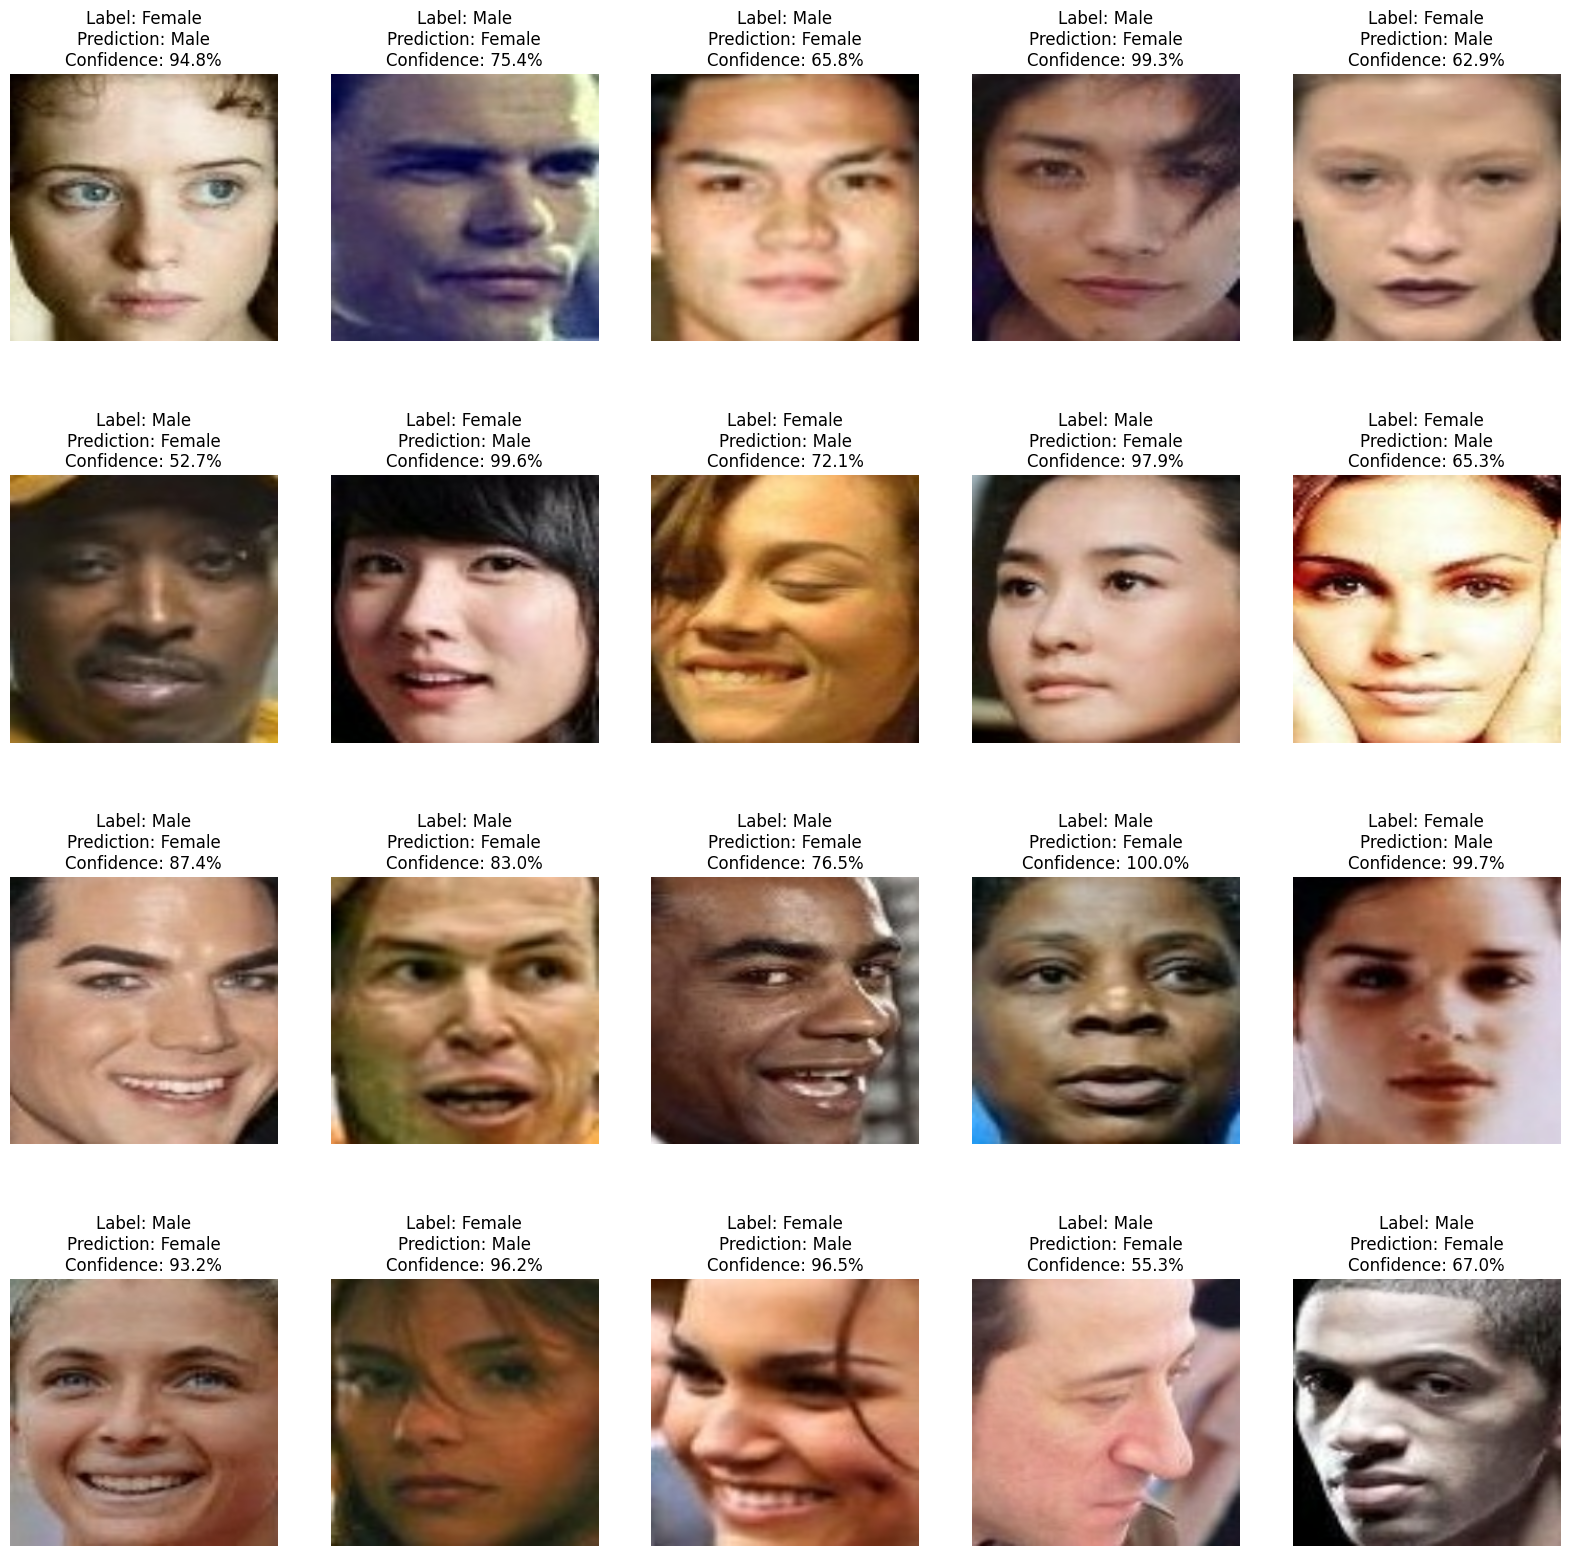

In [41]:

# Plot the mistakes
plt.figure(figsize=(20,20))
for idx, err in enumerate(errors[:20]):
    plt.subplot(4, 5, idx + 1)
    plt.imshow(err['image'])
    plt.title(f"Label: {['Female','Male'][err['true']]}\nPrediction: {['Female','Male'][err['pred']]}\nConfidence: {err['conf']*100:.1f}%")
    plt.axis('off')
plt.show()

According to these images its common, that fuller lips are connected to females, and thus for small lips it easily missclassifies.
On the one before the last img, the model is really unceartain, possibly because really few features can be extracted.
Within the data, we can clearly see, that the model worked well, but the label seems to be wrong 

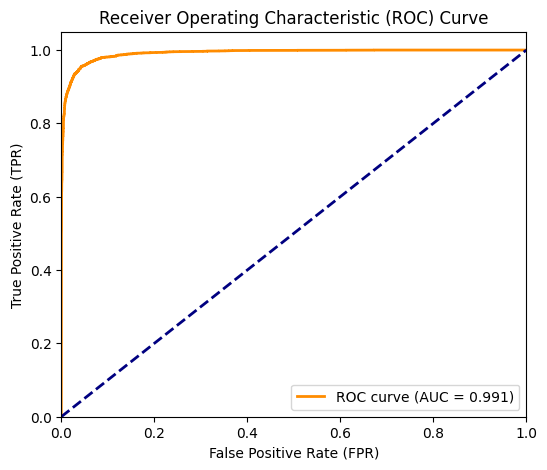

In [ ]:
#Receiver Operating Characteristic
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true_roc, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

This shows, that the model will almost every time give a higher probability score for the correct label and thus classify correctly